# 文件: chart_51_1.py

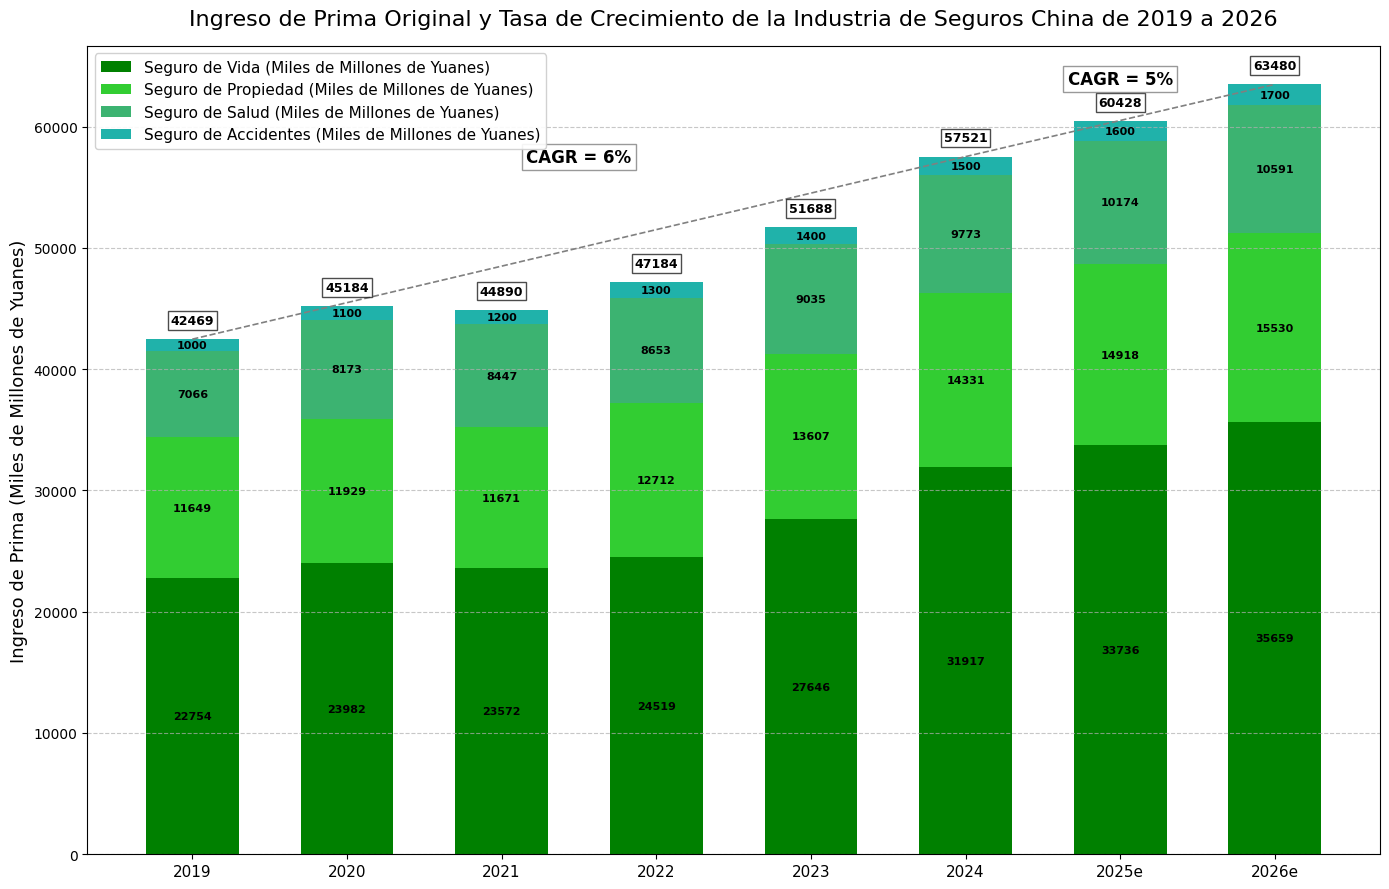

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Años
years = ["2019", "2020", "2021", "2022", "2023", "2024", "2025e", "2026e"]
# Ingresos de prima de cada tipo de seguro (en miles de millones de yuanes), los datos se simulan aproximadamente y se pueden ajustar según las situaciones reales
premium_data = np.array([
    [22754, 11649, 7066, 1000],    # 2019
    [23982, 11929, 8173, 1100],    # 2020
    [23572, 11671, 8447, 1200],    # 2021
    [24519, 12712, 8653, 1300],    # 2022
    [27646, 13607, 9035, 1400],    # 2023
    [31917, 14331, 9773, 1500],    # 2024
    [33736, 14918, 10174, 1600],   # 2025e
    [35659, 15530, 10591, 1700]    # 2026e
])

# Colores correspondientes a cada tipo de seguro
colors = ['green', 'limegreen', 'mediumseagreen', 'lightseagreen']
# Nombres de los tipos de seguro
insurance_types = ["Seguro de Vida (Miles de Millones de Yuanes)", "Seguro de Propiedad (Miles de Millones de Yuanes)", "Seguro de Salud (Miles de Millones de Yuanes)", "Seguro de Accidentes (Miles de Millones de Yuanes)"]

x = np.arange(len(years))  # Posiciones de las marcas en el eje x
bar_width = 0.6  # Ancho de las barras

fig, ax = plt.subplots(figsize=(14, 9))  # Aumentar aún más el tamaño del gráfico

# Dibujar un gráfico de barras apiladas
bottom = np.zeros(len(years))
for i in range(premium_data.shape[1]):
    bars = ax.bar(x, premium_data[:, i], width=bar_width, bottom=bottom, color=colors[i], label=insurance_types[i])
    bottom += premium_data[:, i]
    
    # Agregar etiquetas de datos encima de cada barra
    for j, bar in enumerate(bars):
        height = bar.get_height()
        if height > 500:  # Mostrar solo etiquetas con altura suficiente para evitar la sobrecarga
            ax.text(
                bar.get_x() + bar.get_width()/2., 
                bar.get_y() + height/2,
                f'{int(height)}',
                ha='center', va='center',
                color='black', fontsize=8, fontweight='bold'
            )

# Agregar un título
ax.set_title('Ingreso de Prima Original y Tasa de Crecimiento de la Industria de Seguros China de 2019 a 2026', fontsize=16, pad=15)

# Establecer las etiquetas de las marcas en el eje x
ax.set_xticks(x)
ax.set_xticklabels(years, fontsize=11)

# Agregar una etiqueta al eje y
ax.set_ylabel('Ingreso de Prima (Miles de Millones de Yuanes)', fontsize=13)

# Agregar una leyenda
ax.legend(loc='upper left', frameon=True, framealpha=0.9, fontsize=11)

# Calcular la prima total para cada año
total_premiums = premium_data.sum(axis=1)

# Agregar anotaciones de prima total
for i, total in enumerate(total_premiums):
    ax.text(x[i], total + 1000,  # Ajustar la posición vertical para evitar superposición con las barras
            f'{int(total)}', 
            ha='center', va='bottom', 
            fontsize=9, fontweight='bold',
            bbox=dict(facecolor='white', alpha=0.7, pad=2.0))

# Función de anotación de CAGR
def add_cagr_annotation(start_idx, end_idx, cagr_value, ax, x, total_premiums):
    """Agregar anotación de polilínea de CAGR"""
    start_x = x[start_idx]
    end_x = x[end_idx]
    start_y = total_premiums[start_idx]
    end_y = total_premiums[end_idx]
    
    # Calcular la posición del punto medio
    mid_x = (start_x + end_x) / 2
    mid_y1 = start_y + (end_y - start_y) * 0.3
    mid_y2 = start_y + (end_y - start_y) * 0.7
    
    # Dibujar una polilínea
    ax.plot([start_x, end_x], [start_y, end_y], 
            'gray', linestyle='--', linewidth=1.2)
    
    # Agregar texto de CAGR
    text_x = mid_x
    text_y = mid_y2 + (end_y - start_y) * 0.25
    ax.text(text_x, text_y, f'CAGR = {cagr_value}%', 
            ha='center', va='bottom', fontsize=12, fontweight='bold',
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray', pad=3.0))

# Agregar anotación de CAGR de 2019 a 2024
add_cagr_annotation(0, 5, 6, ax, x, total_premiums)

# Agregar anotación de CAGR de 2024 a 2026
add_cagr_annotation(5, 7, 5, ax, x, total_premiums)

# Embelezar el gráfico
plt.grid(axis='y', linestyle='--', alpha=0.7)  # Agregar líneas de cuadrícula horizontales
plt.tight_layout()  # Ajustar automáticamente el diseño

plt.show()

# 文件: chart_51_2.py

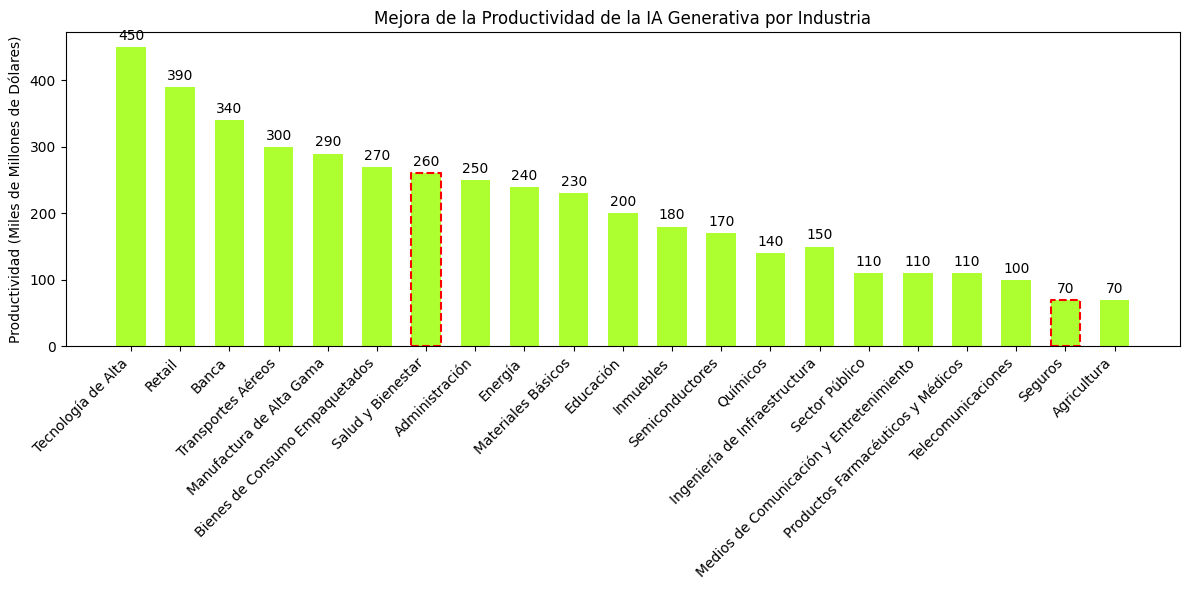

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# Nombres de las industrias
industrias = ["Tecnología de Alta", "Retail", "Banca", "Transportes Aéreos", "Manufactura de Alta Gama",
              "Bienes de Consumo Empaquetados", "Salud y Bienestar", "Administración", "Energía", "Materiales Básicos",
              "Educación", "Inmuebles", "Semiconductores", "Químicos", "Ingeniería de Infraestructura",
              "Sector Público", "Medios de Comunicación y Entretenimiento", "Productos Farmacéuticos y Médicos",
              "Telecomunicaciones", "Seguros", "Agricultura"]
# Datos de productividad (en miles de millones de dólares), aproximadamente simulados y se pueden ajustar según la situación real
productividad = [450, 390, 340, 300, 290, 270, 260, 250, 240, 230, 200, 180, 170, 140, 150, 110, 110, 110, 100, 70, 70]
# Marcar los índices de las industrias que necesitan un marco especial
indices_especiales = [6, 19]  # Índices correspondientes a Salud y Bienestar, Seguros

x = np.arange(len(industrias))  # Posiciones de las marcas en el eje x
ancho_barra = 0.6  # Ancho de las barras

fig, ax = plt.subplots(figsize=(12, 6))

# Dibujar un gráfico de barras, establecer el color a un verde similar
barras = ax.bar(x, productividad, width=ancho_barra, color='greenyellow')

# Agregar un título
ax.set_title('Mejora de la Productividad de la IA Generativa por Industria')

# Establecer las etiquetas de las marcas en el eje x, girarlas en un cierto ángulo para evitar superposiciones
ax.set_xticks(x)
ax.set_xticklabels(industrias, rotation=45, ha='right')

# Agregar cuadros discontinuos rojos para las industrias especiales
for idx in indices_especiales:
    rect = barras[idx].get_bbox()
    ax.plot([rect.x0, rect.x1, rect.x1, rect.x0, rect.x0],
            [rect.y0, rect.y0, rect.y1, rect.y1, rect.y0],
            'r--', linewidth=1.5)

# Agregar etiquetas numéricas a cada barra
for barra in barras:
    altura = barra.get_height()
    ax.annotate(f'{altura}',
                xy=(barra.get_x() + barra.get_width() / 2, altura),
                xytext=(0, 3),  # Desplazamiento vertical de 3 puntos
                textcoords="offset points",
                ha='center', va='bottom')

# Establecer la etiqueta del eje y
ax.set_ylabel('Productividad (Miles de Millones de Dólares)')

plt.tight_layout()  # Ajustar automáticamente el diseño para evitar superposiciones de etiquetas
plt.show()

# 文件: chart_51_3.py

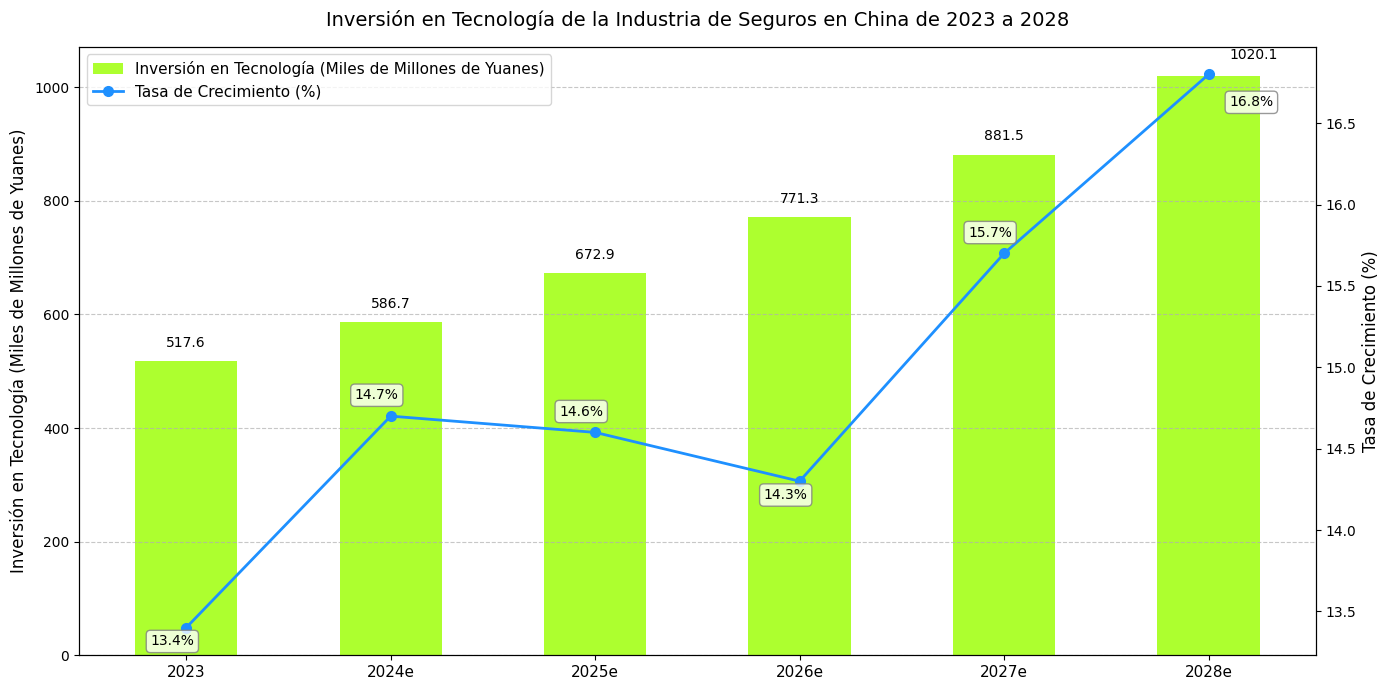

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# Años
years = ["2023", "2024e", "2025e", "2026e", "2027e", "2028e"]
# Inversión en tecnología (en miles de millones de yuanes), aproximadamente simulada y se puede ajustar según la situación real
tech_investment = [517.6, 586.7, 672.9, 771.3, 881.5, 1020.1]
# Tasa de crecimiento (%), aproximadamente simulada y se puede ajustar según la situación real
growth_rate = [13.4, 14.7, 14.6, 14.3, 15.7, 16.8]

x = np.arange(len(years))  # Posiciones de las marcas en el eje x
bar_width = 0.5  # Ancho de las barras

fig, ax1 = plt.subplots(figsize=(14, 7))  # Aumentar aún más el ancho del gráfico

# Dibujar el gráfico de barras de la inversión en tecnología
bars = ax1.bar(x, tech_investment, width=bar_width, label='Inversión en Tecnología (Miles de Millones de Yuanes)', color='greenyellow')
ax1.set_ylabel('Inversión en Tecnología (Miles de Millones de Yuanes)', fontsize=12)
ax1.set_xticks(x)
ax1.set_xticklabels(years, fontsize=11)

# Agregar etiquetas numéricas al gráfico de barras
for i, bar in enumerate(bars):
    height = bar.get_height()
    # Manejo especial para la última etiqueta
    if i == len(bars) - 1:
        ax1.annotate(f'{tech_investment[i]}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(15, 10),  # Desplazamiento hacia la parte superior derecha
                    textcoords="offset points",
                    ha='left', va='bottom',  # Alineación a la izquierda, abajo
                    fontsize=10)
    else:
        ax1.annotate(f'{tech_investment[i]}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 8),
                    textcoords="offset points",
                    ha='center', va='bottom',
                    fontsize=10)

# Crear un segundo eje y y dibujar el gráfico de línea de la tasa de crecimiento
ax2 = ax1.twinx()
line, = ax2.plot(x, growth_rate, marker='o', markersize=7, label='Tasa de Crecimiento (%)', 
                color='dodgerblue', linewidth=2)
ax2.set_ylabel('Tasa de Crecimiento (%)', fontsize=12)

# Agregar etiquetas numéricas al gráfico de línea
for i, rate in enumerate(growth_rate):
    # Manejo especial para la última etiqueta
    if i == len(growth_rate) - 1:
        ax2.annotate(f'{rate}%',
                    xy=(x[i], rate),
                    xytext=(15, -15),  # Desplazamiento hacia la parte inferior derecha
                    textcoords="offset points",
                    ha='left', va='top',  # Alineación a la izquierda, arriba
                    fontsize=10,
                    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8))
    else:
        ax2.annotate(f'{rate}%',
                    xy=(x[i], rate),
                    xytext=(-10, 10) if rate > 14.5 else (-10, -15),
                    textcoords="offset points",
                    ha='center', va='bottom',
                    fontsize=10,
                    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8))

# Agregar un título
ax1.set_title('Inversión en Tecnología de la Industria de Seguros en China de 2023 a 2028', fontsize=14, pad=15)

# Combinar las leyendas
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left', fontsize=11)

# Embellir el gráfico
ax1.grid(axis='y', linestyle='--', alpha=0.7)  # Agregar líneas de cuadrícula horizontales
plt.tight_layout()  # Ajustar automáticamente el diseño

plt.show()

# 文件: chart_51_4.py

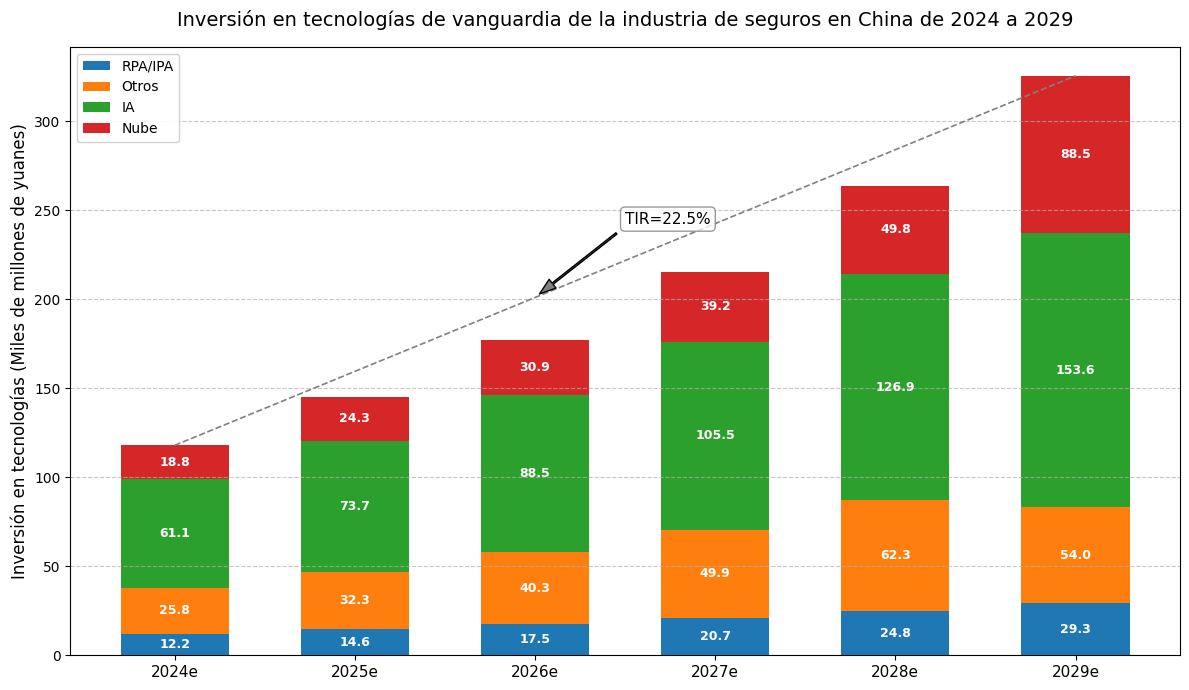

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# Años
years = ["2024e", "2025e", "2026e", "2027e", "2028e", "2029e"]

# Datos de inversión para cada tecnología (en miles de millones de yuanes), en el orden de RPA/IPA, Otros, IA, Nube, Big Data
# Nota: El último valor se calcula restando los valores anteriores del total para asegurar que la suma de cada capa sea correcta
tech_investment = np.array([
    [12.2, 25.8, 61.1, 117.9 - (12.2 + 25.8 + 61.1)],  # Total en 2024e: 12.2+25.8+61.1+18.8=117.9
    [14.6, 32.3, 73.7, 144.9 - (14.6 + 32.3 + 73.7)],  # Total en 2025e: 14.6+32.3+73.7+24.3=144.9
    [17.5, 40.3, 88.5, 177.2 - (17.5 + 40.3 + 88.5)],  # Total en 2026e: 17.5+40.3+88.5+30.9=177.2
    [20.7, 49.9, 105.5, 215.3 - (20.7 + 49.9 + 105.5)],# Total en 2027e: 20.7+49.9+105.5+39.2=215.3
    [24.8, 62.3, 126.9, 263.8 - (24.8 + 62.3 + 126.9)],# Total en 2028e: 24.8+62.3+126.9+50.0=263.8
    [29.3, 54.0, 153.6, 325.4 - (29.3 + 54.0 + 153.6)] # Total en 2029e: 29.3+54.0+153.6+88.5=325.4
])

# Colores correspondientes a cada tecnología (tan cercanos como sea posible a la imagen original)
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

# Nombres de las tecnologías (con unidades)
tech_names = ["RPA/IPA", "Otros", "IA", "Nube", "Big Data"]

x = np.arange(len(years))  # Posiciones de las marcas en el eje x
bar_width = 0.6  # Ancho del gráfico de barras

fig, ax = plt.subplots(figsize=(12, 7))

# Dibujar el gráfico de barras apiladas
bottom = np.zeros(len(years))
for i in range(tech_investment.shape[1]):
    bars = ax.bar(x, tech_investment[:, i], width=bar_width, bottom=bottom, 
                  color=colors[i], label=tech_names[i])
    bottom += tech_investment[:, i]
    
    # Etiquetar los valores en cada capa apilada
    for j, bar in enumerate(bars):
        height = bar.get_height()
        if height > 0:  # Etiquetar solo valores no nulos
            ax.text(
                bar.get_x() + bar.get_width()/2, 
                bar.get_y() + height/2,
                f'{height:.1f}',
                ha='center', va='center',
                color='white', fontsize=9, fontweight='bold'
            )

# Agregar el título
ax.set_title('Inversión en tecnologías de vanguardia de la industria de seguros en China de 2024 a 2029', fontsize=14, pad=15)

# Establecer las etiquetas de las marcas en el eje x
ax.set_xticks(x)
ax.set_xticklabels(years, fontsize=11)

# Agregar la etiqueta del eje y
ax.set_ylabel('Inversión en tecnologías (Miles de millones de yuanes)', fontsize=12)

# Agregar la leyenda (ubicada en el lado derecho del gráfico)
ax.legend(loc='upper left', frameon=True, framealpha=0.9, fontsize=10)

# Calcular y etiquetar la TIR (22.5%)
cagr = 22.5
start_value = tech_investment[0].sum()
end_value = tech_investment[-1].sum()

# Dibujar la línea de la TIR
ax.plot([x[0], x[-1]], [start_value, end_value], 'gray', linestyle='--', linewidth=1.2)

# Agregar la etiqueta de texto de la TIR
ax.annotate(
    f'TIR={cagr}%', 
    xy=(x[2], start_value + (end_value - start_value)*0.4), 
    xytext=(x[2]+0.5, start_value + (end_value - start_value)*0.6),
    arrowprops=dict(facecolor='gray', shrink=0.05, width=1.2, headwidth=8),
    fontsize=11,
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8)
)

# Embelezar el gráfico
plt.grid(axis='y', linestyle='--', alpha=0.7)  # Agregar líneas de cuadrícula horizontales
plt.tight_layout()  # Ajustar automáticamente el diseño

plt.show()

# 文件: chart_51_5.py

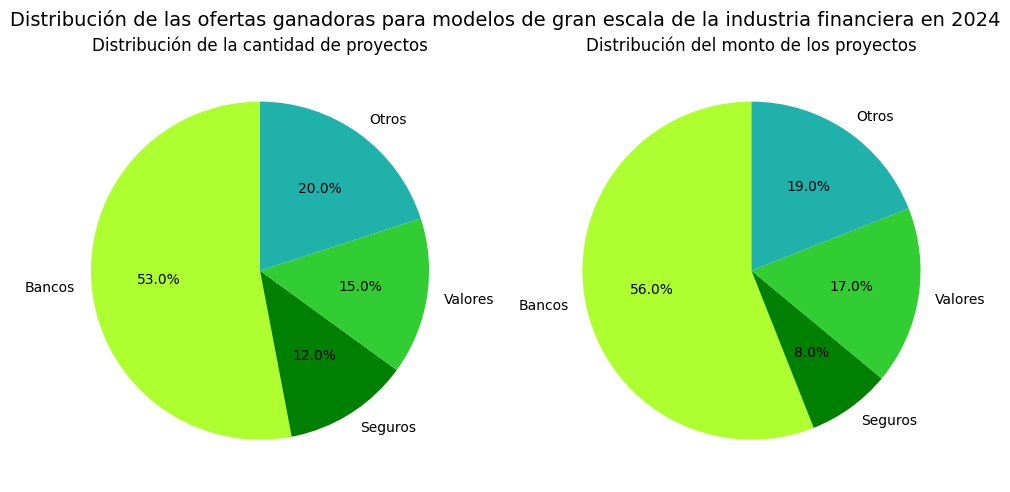

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# Definición de datos, distribución de la cantidad de proyectos y distribución del monto de los proyectos
etiquetas = ["Bancos", "Seguros", "Valores", "Otros"]
tamaños_cantidad = [53, 12, 15, 20]  # Distribución de la cantidad de proyectos, simulada aproximadamente
tamaños_monto = [56, 8, 17, 19]  # Distribución del monto de los proyectos, simulada aproximadamente
# Configuración de colores, lo más cercano posible a la imagen original
colores = ["greenyellow", "green", "limegreen", "lightseagreen"]

# Crear un lienzo y subgráficos
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

# Dibujar un gráfico circular de la distribución de la cantidad de proyectos
ax1.pie(tamaños_cantidad, labels=etiquetas, autopct='%1.1f%%', startangle=90, colors=colores)
ax1.set_title('Distribución de la cantidad de proyectos')

# Dibujar un gráfico circular de la distribución del monto de los proyectos
ax2.pie(tamaños_monto, labels=etiquetas, autopct='%1.1f%%', startangle=90, colors=colores)
ax2.set_title('Distribución del monto de los proyectos')

# Agregar un título principal
fig.suptitle('Distribución de las ofertas ganadoras para modelos de gran escala de la industria financiera en 2024', fontsize=14)

plt.tight_layout()
plt.show()